In [1]:
import pandas as pd
import re
import torch
#libraries for data exploration
import seaborn as sns
import matplotlib.pyplot as plt

#libraries for model training and evaluation
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer,BertForSequenceClassification
from transformers import Trainer,TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import accuracy_score,precision_recall_fscore_support

In [21]:
df=pd.read_csv("phishing_email.csv")
df.shape

(82486, 2)

In [22]:
df=df.sample(n=15000,random_state=42).reset_index(drop=True)
print(df.head())

                                       text_combined  label
0  endangered languages workshop foundation endan...      0
1  claretta claretta_bordersfusemailcom cialis wo...      1
2  roger upole schkeramsncom kyle rickey wrote im...      0
3  barclays customer service testlightworldcojp d...      1
4  gmm 09 nov 2001 please find attached global ma...      0


In [23]:
print(df.columns)

Index(['text_combined', 'label'], dtype='object')


Preprocess the Data
*Remove null
*convert lower


In [24]:
df.dropna(inplace=True)
df['label']=df['label'].astype(int)

def clean_text(text):
  return text.lower()
df['text_combined']=df['text_combined'].apply(clean_text)


In [25]:
print(df.info())
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  15000 non-null  object
 1   label          15000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 234.5+ KB
None


(15000, 2)

# Explore the dataset

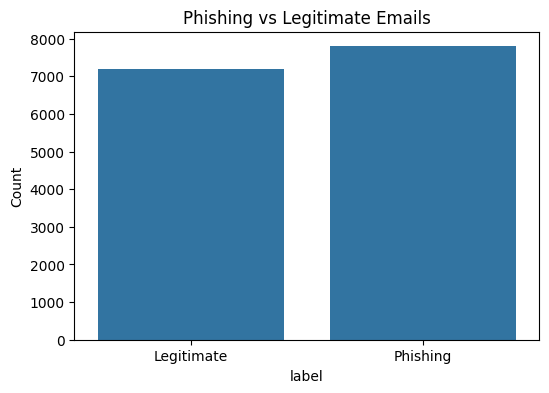

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='label')
plt.title("Phishing vs Legitimate Emails")
plt.xticks([0,1],['Legitimate','Phishing'])
plt.ylabel("Count")
plt.show()

Email/text special character length Distribution by Class .This is a boxplot comparing no of special characters used in legitimae vs phishing emails

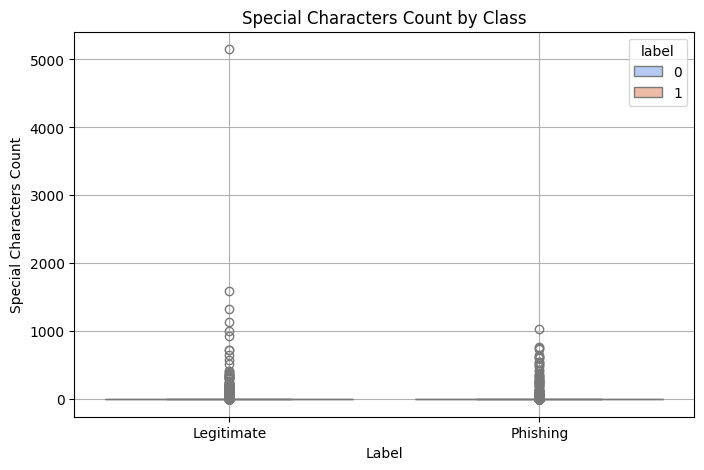

In [27]:
df['special_chars']=df['text_combined'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x))
plt.figure(figsize=(8,5))
sns.boxplot(x="label",y='special_chars',data=df,hue='label',palette='coolwarm',dodge=False)
plt.xticks([0,1],['Legitimate','Phishing'])
plt.title("Special Characters Count by Class")
plt.xlabel('Label')
plt.ylabel('Special Characters Count')
plt.grid(True)
plt.show()

Most Common Words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


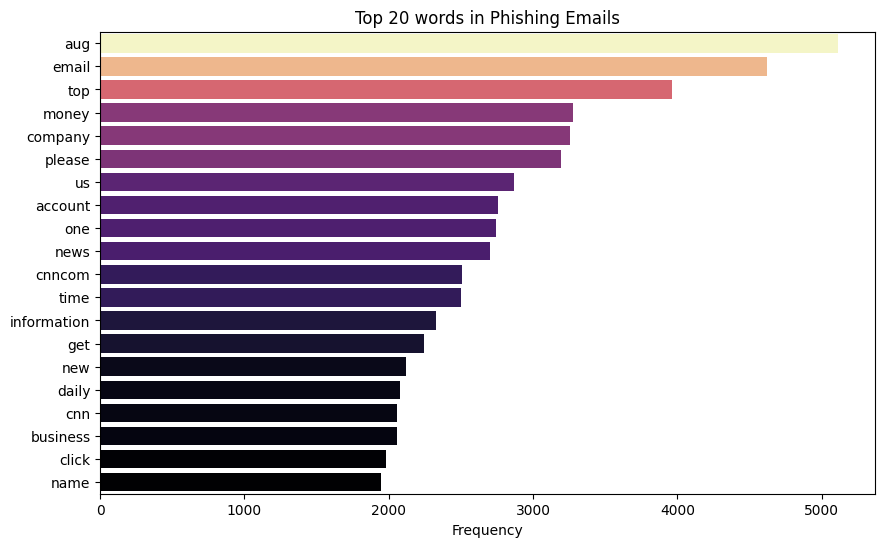

In [28]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words=set(stopwords.words('english'))
phishing_words=' '.join(df[df['label']==1]['text_combined']).lower().split()

filtered_words=[word for word in phishing_words if word.isalpha() and word not in stop_words]

word_freq=Counter(filtered_words).most_common(20)

words,count=zip(*word_freq)
plt.figure(figsize=(10,6))
sns.barplot(x=list(count),y=list(words),hue=list(count),palette='magma',legend=False)
plt.title('Top 20 words in Phishing Emails')
plt.xlabel('Frequency')
plt.show()

In [29]:
train_texts,test_texts,train_labels,test_labels=train_test_split(
    df['text_combined'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [30]:
tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [31]:
train_encodings=tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings=tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [32]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx])
                for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [33]:
train_dataset = EmailDataset(
    train_encodings,
    train_labels.tolist()
)

test_dataset = EmailDataset(
    test_encodings,
    test_labels.tolist()
)

In [34]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [35]:
def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='binary'
    )

    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [36]:
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs',
    logging_steps=100
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [37]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(tokenizer)
)

In [38]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.070102,0.084330,0.981000,0.987662,0.975625,0.981607
2,0.008553,0.083491,0.985333,0.989657,0.982040,0.985834


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.10132640371719996, metrics={'train_runtime': 645.9043, 'train_samples_per_second': 37.157, 'train_steps_per_second': 4.645, 'total_flos': 1578666332160000.0, 'train_loss': 0.10132640371719996, 'epoch': 2.0})

In [39]:
results = trainer.evaluate()

print(results)

{'eval_loss': 0.08349147439002991, 'eval_accuracy': 0.9853333333333333, 'eval_precision': 0.9896574014221073, 'eval_recall': 0.9820397690827454, 'eval_f1': 0.9858338699291693, 'eval_runtime': 22.3736, 'eval_samples_per_second': 134.087, 'eval_steps_per_second': 16.761, 'epoch': 2.0}


In [40]:
model.save_pretrained("./phishing_model")
tokenizer.save_pretrained("./phishing_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./phishing_model/tokenizer_config.json', './phishing_model/tokenizer.json')

In [41]:
email = """
Urgent! Your account has been suspended.
Click the link below immediately.
"""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

inputs = tokenizer(
    email,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

inputs = {key: value.to(device) for key, value in inputs.items()}

outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

if prediction == 1:
    print("Phishing Email")
else:
    print("Legitimate Email")

Phishing Email


In [42]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = test_labels.tolist()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1441
           1       0.99      0.98      0.99      1559

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



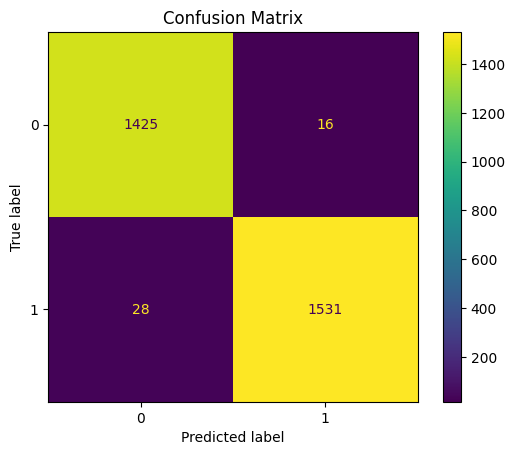

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [45]:
model.save_pretrained("phishing_model")
tokenizer.save_pretrained("phishing_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('phishing_model/tokenizer_config.json', 'phishing_model/tokenizer.json')

In [47]:
def predict_email(email_text):

    device = next(model.parameters()).device

    inputs = tokenizer(
        email_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    if pred == 1:
        return "Phishing Email"
    else:
        return "Legitimate Email"

In [48]:
print(predict_email(
    "Congratulations! You won $10,000. Click here to claim."
))

print(predict_email(
    "Hi team, the meeting is scheduled at 3 PM tomorrow."
))

print(predict_email(
    "Verify your bank account immediately or it will be suspended."
))

Phishing Email
Legitimate Email
Phishing Email


In [49]:
import os
print(os.path.exists("phishing_model"))

True


In [50]:
!zip -r phishing_model.zip phishing_model

  adding: phishing_model/ (stored 0%)
  adding: phishing_model/config.json (deflated 53%)
  adding: phishing_model/tokenizer_config.json (deflated 42%)
  adding: phishing_model/tokenizer.json (deflated 71%)
  adding: phishing_model/model.safetensors (deflated 7%)


In [51]:
from google.colab import files
files.download("phishing_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>